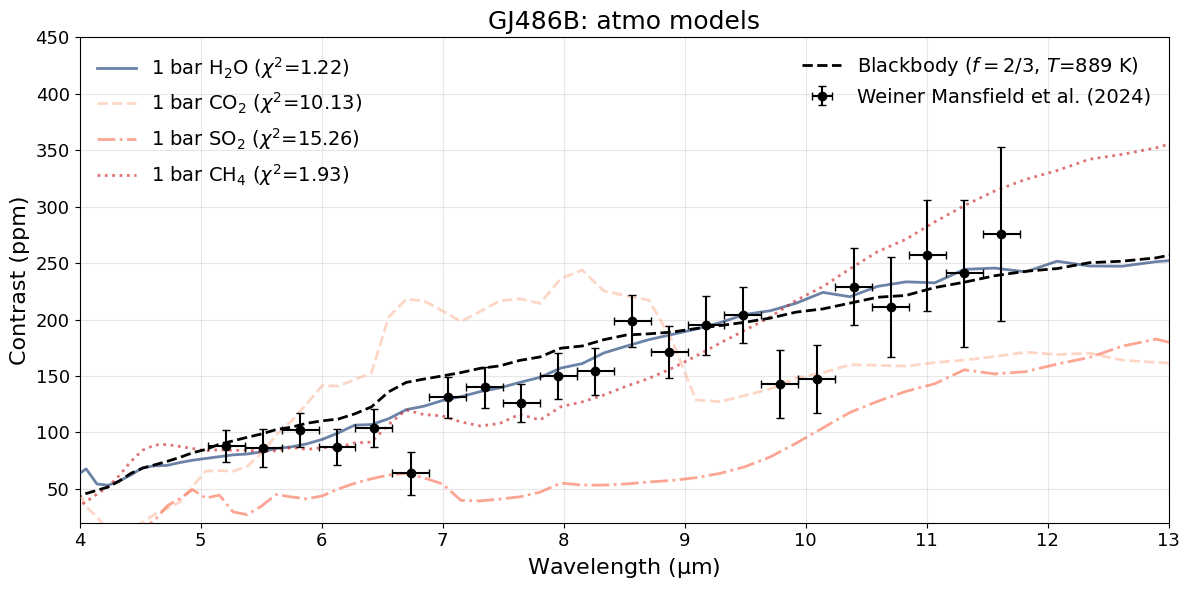

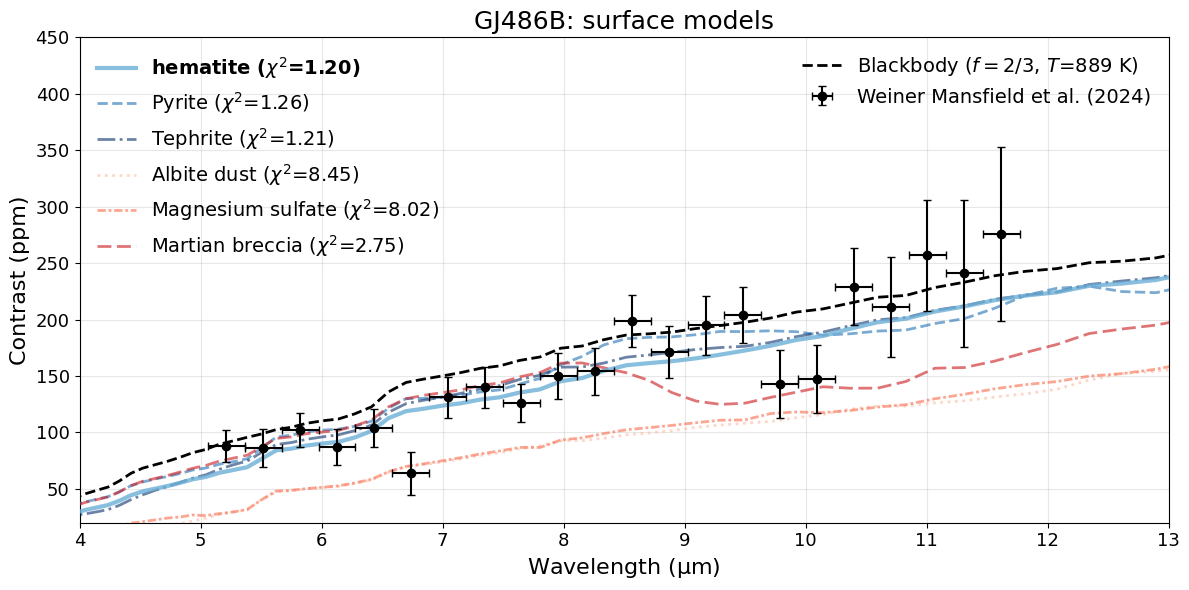

In [1]:
import sys
sys.path.append("/Users/users/stuitje/FWhome/VAYU")  # repo root

from plt.plots_paper import plot_contrasts, ATMOSPHERE_LABELS, DEFAULT_SURFACE_LABELS

subset_atm = [
    "1bar_H2O",
    "1bar_CO2",
    "1bar_CH4",
    "1bar_SO2",
]
subset_surf = [
    "hematite",
    "pyrite",
    "tephrite",
    "albite_dust",
    "magnesium_sulphate",
    "mars_breccia"
]
# Atmosphere mode
plot_contrasts(
    planet="gj486b",
    mode="atmo",
    keys=subset_atm,
    labels=ATMOSPHERE_LABELS,
    ylim=(20, 450),
    xlim=(4, 13),
)

# Surface mode
plot_contrasts(
    planet="gj486b",
    mode="surface",
    keys=subset_surf,
    labels=DEFAULT_SURFACE_LABELS,
    highlights=["hematite"],
    ylim=(20, 450),
    xlim=(4, 13),
)

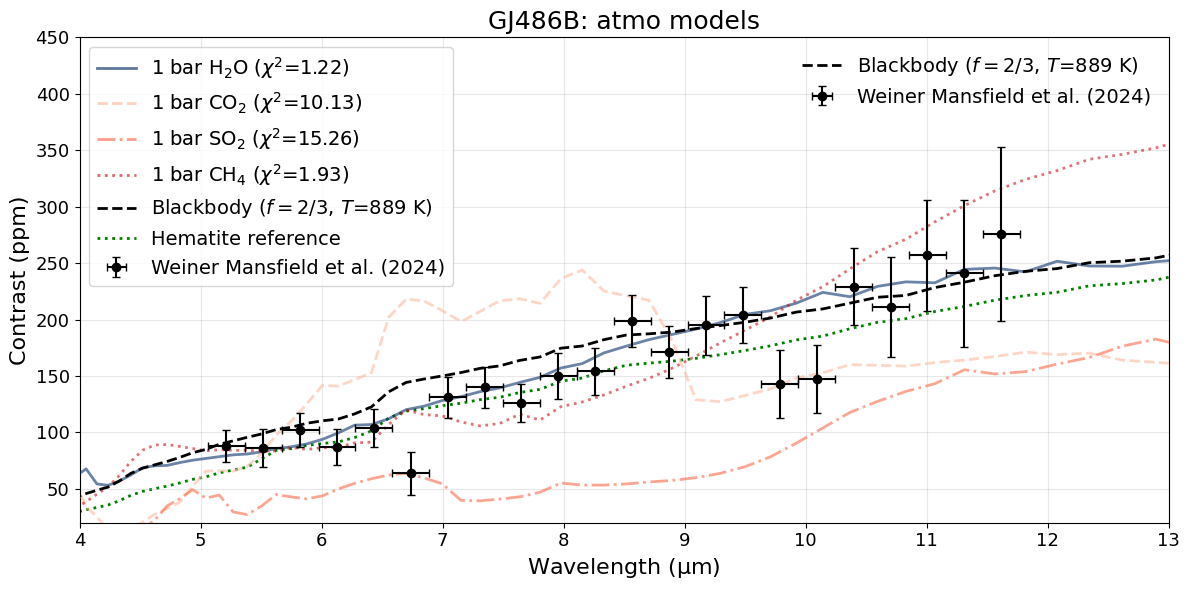

In [ ]:
import os
import matplotlib.pyplot as plt
from src.dataloader import load_agni_output, get_planet_data
from src.utils import contrast_ppm
from src.constants import r_earth, r_sun
from plt.plots_paper import plot_contrasts, ATMOSPHERE_LABELS, CONFIG, ROOT, get_star_spectrum_path

# Make the main figure
plot_contrasts(
    planet="gj486b",
    mode="atmo",
    keys=subset_atm,
    labels=ATMOSPHERE_LABELS,
    ylim=(20, 450),
    xlim=(4, 13),
)

# Grab the current axes and overlay hematite
ax = plt.gca()
pdata = get_planet_data("gj486b")
nc_path = os.path.join(CONFIG["output_dir"], "gj486b", "hematite", "bare_rock", "atm.nc")
data = load_agni_output(nc_path)
hematite_contrast = contrast_ppm(
    wavelength_nm=data["bandcenter"],
    T_star=pdata["star_temp"],
    R_planet_m=pdata["planet_radius"] * r_earth,
    R_star_m=pdata["star_radius"] * r_sun,
    planet_flux=data["ba_U_total"],
    stellar_spectrum=get_star_spectrum_path("gj486b"),
)
ax.plot(data["bandcenter"] / 1000, hematite_contrast,
        color="green", linestyle="dotted", linewidth=2,
        label="Hematite reference surface", zorder=1)
ax.legend()  # rebuild to include hematite
plt.show()